#  Классификация текстов с использованием эмбеддингов слов.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://rusvectores.org/
* https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
* https://github.com/natasha/navec
* https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html
* https://torchmetrics.readthedocs.io/en/stable/
* https://github.com/natasha/navec

## Задачи для совместного разбора

1\. Реализуйте модель для классификации текстов с использованием слоя `nn.Embedding`. Заморозьте веса слоя эмбеддингов.

In [1]:
import torch as th

X = th.randint(0, 1000, size=(16, 20)).long()
y = th.full(size=(16, ), fill_value=0.5).bernoulli().long()

In [2]:
import torch.nn as nn

class Net(nn.Module):
  def __init__(
      self,
      num_embeddings: int,
      embedding_dim: int,
      num_classes: int) -> None:
    super().__init__()
    self.embedding = nn.Embedding(
        num_embeddings,
        embedding_dim
    )
    self.fc = nn.Linear(embedding_dim, num_classes)

  def forward(self, X):
     e = self.embedding(X) # b x s x e
     e_s = e.mean(dim=1)
     out = self.fc(e_s)
     return out

## Задачи для самостоятельного решения

In [39]:
import pandas as pd
import nltk
import gensim
import pymorphy3
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer, word_tokenize
from nltk.util import ngrams
import torch as th
from gensim.models import Word2Vec
import random
from functools import reduce
from torch.utils.data import Dataset
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import itertools
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from functools import reduce
from nltk.tokenize import RegexpTokenizer
import pandas as pd
import time
import torch
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers.normalizers import Lowercase, Strip, Replace, Sequence as NormalizerSequence
from tokenizers import Regex
from tokenizers.processors import TemplateProcessing
from itertools import permutations
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer
import torch.optim as optim
from torchmetrics.classification import MulticlassF1Score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tqdm.notebook import tqdm
from navec import Navec

[nltk_data] Downloading package stopwords to C:\Users\Rog
[nltk_data]     G16\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<p class="task" id="1"></p>

1\. Считайте файл `lenta_news.csv` и разбейте на обучающую и тестовую выборку. Выполните предобработку текста и создайте Tokenizer на основе обучающей выборки (токен - слово). Выведите на экран количество токенов в полученном словаре. Обратите внимание, что построение словаря токенов должно производиться исключительно на основе обучающей выборки.

- [ ] Проверено на семинаре

In [4]:
df = pd.read_csv("data/lenta_news.csv")

all_texts = df['text'].values
all_labels = df['topic'].values 


train_texts, test_texts, train_labels, test_labels = train_test_split(
    all_texts, all_labels, test_size=0.2, stratify=all_labels
)

In [7]:
tokenizer = RegexpTokenizer(r"[A-zА-я]+")


morph = pymorphy3.MorphAnalyzer()

ru_stops = set(stopwords.words('russian'))
en_stops = set(stopwords.words('english'))

            
text2index = {}
index2text = {}
for idx, text in enumerate(train_texts):
    
    sirye = tokenizer.tokenize(text)
    
    tokens = []
    for word in sirye :
        word = word.lower()
        if word not in ru_stops and word not in en_stops:
            tokens.append(morph.parse(word)[0].normal_form)
    text2index[text] = idx
    index2text[idx] = tokens

0it [00:00, ?it/s]

In [8]:
tokenizer_ws = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer_ws.pre_tokenizer = Whitespace()
trainer_ws = WordLevelTrainer(special_tokens=["[PAD]", "[UNK]", "[SOS]", "[EOS]"], vocab_size=1000000)

tokenizer_ws.train_from_iterator(index2text.values(), trainer=trainer_ws)
# tokenizer_ws.enable_padding(
#     pad_id=tokenizer_ws.token_to_id("[PAD]"),
#     pad_token="[PAD]",
#     length=400
# )

In [9]:
tokenizer_ws.decode(range(10))

'год который свой компания россия сообщать'

In [10]:
tokenizer_ws.get_vocab()['[PAD]']

0

In [11]:
len(tokenizer_ws.get_vocab())

84613

In [12]:
np.mean(list(map(lambda x: len(x), index2text.values())))

np.float64(127.7231588287489)

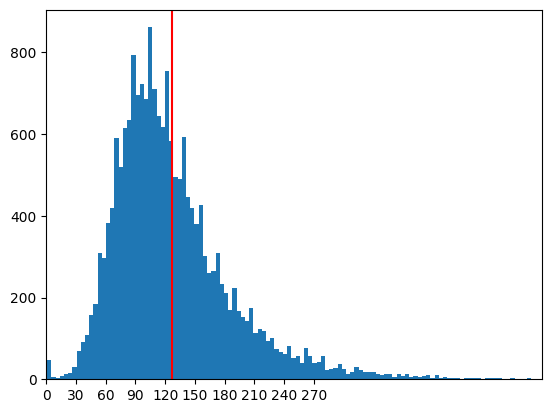

In [13]:
plt.hist(list(map(lambda x: len(x), index2text.values())), bins=200)
plt.xticks([i*30 for i in range(10)])
plt.xlim((0,500))
plt.axvline(127, c='r')
plt.show()

<p class="task" id="2"></p>


2\. Создайте класс `NewsDataset`. Реализуйте метод `__getitem__` таким образом, чтобы он возвращал набор индексов токенов для текста новости $i$ и метку класса для этой новости. Сделайте длины наборов индексов одинаковой фиксированной длины (подходящее значение определите сами). Используйте индекс 0 для паддинга. Закодируйте целыми числами категории новостей. Создайте два объекта класса `NewsDataset` (для обучающей и тестовой выборки).

Выведите на экран результат выполнения `train_dataset[0]`

- [ ] Проверено на семинаре

In [14]:
class PadTruncate:
    def __init__(self, n, pad_idx=0):
        self.n = n
        self.pad_idx = pad_idx
    
    def __call__(self, text):
        if len(text) >= self.n:
            return text[:self.n]
        else:
            return text + [self.pad_idx] * (self.n - len(text))


class NewsDataset(Dataset):
    def __init__(self, 
                 texts: list[str], 
                 labels: list[str], 
                 tokenizer, 
                 max_length: int = 40,
                 label2id: dict[str, int] = None):
        
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.pad_trun = PadTruncate(self.max_length)
        
        if label2id is None:
            unique_labels = sorted(list(set(labels)))
            self.label2id = {label: i for i, label in enumerate(unique_labels)}
        else:
            self.label2id = label2id
        
        self.pretokenized_ids = []
        
        some_tokenizer = RegexpTokenizer(r"[A-zА-я]+")
        

        for text in tqdm(self.texts):
            
            sirye = some_tokenizer.tokenize(str(text))
            tokens = []
            for word in sirye:
                word = word.lower()
                if word not in ru_stops and word not in en_stops:
                    res = morph.parse(word)
                    if res:
                        tokens.append(res[0].normal_form)
            
            encoded = self.tokenizer.encode(tokens, is_pretokenized=True).ids
            fixed_ids = self.pad_trun(encoded)
            self.pretokenized_ids.append(torch.tensor(fixed_ids, dtype=torch.long))
            
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int):
        # Теперь это работает мгновенно!
        label_str = self.labels[idx]
        label_id = self.label2id[label_str]
        
        return self.pretokenized_ids[idx], torch.tensor(label_id, dtype=torch.long)

In [15]:
train_dataset = NewsDataset(
    texts=train_texts,
    labels=train_labels,
    tokenizer=tokenizer_ws,
    max_length=127
)

test_dataset = NewsDataset(
    texts=test_texts,
    labels=test_labels,
    tokenizer=tokenizer_ws,
    max_length=127,
    label2id=train_dataset.label2id
)

print(f"Пример: {train_dataset[1]}\n")

print(f"Классы: {train_dataset.label2id}")

  0%|          | 0/19159 [00:00<?, ?it/s]

  0%|          | 0/4790 [00:00<?, ?it/s]

Пример: (tensor([  814,  6848,     8,   297,   202,   896,    18,   778,  2291,  2491,
            9,  1564,   519,    21,  2320,   217,  6848,   106,   809, 10885,
           26,   297,    60,    32,   782,   202,    20,  5951,   213,   778,
         4000,  2491,  2155, 10723,   202,    16,    20,  5190,  2491,  2925,
           31,   133,    32,   782,    88,   906,    20,   276,     4,    60,
          107,  6848,   117,  1722,   686,  2117,  2194,    88,  2291,   906,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0

<p class="task" id="3"></p>

3\. Реализуйте модель для классификации текстов. Архитектура:
- слой `nn.Embedding` (матрица эмбеддингов инициализируется случайным образом; обязательно укажите padding_idx)
- агрегация : для получения эмбеддинга для новости на основе эмбеддингов слов воспользуйтесь любой функцией агрегации, сохраняющей размерности векторов (сумма, усреднение и т.д.). Если используете среднее, помните, что паддинги (нули) занижают среднее значение - это нужно учесть
- классификатор:  состоит из некоторого количества полносвязных слоев (рекомендуется добавить dropout для регуляризации)

Решите задачу классификации новостей. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики f1 на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран отчет по классификации на обучающем и тестовом множестве.

- [ ] Проверено на семинаре

In [16]:
batch_size = 128

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=0
)

In [17]:
class IvanTishchenkoPL(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim=100, num_classes=4, padding_idx=0):
        super().__init__()
        self.save_hyperparameters()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=padding_idx
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )

        self.train_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.test_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.history = {'train_loss': [], 'train_f1': [], 'test_f1': []}

    def forward(self, x):
        # x: [Batch_Size, Seq_Len] ->  [128, 127]
        embeds = self.embedding(x) # [128, 127, 100]
        
        # Создаем маску для реальных слов (не паддингов)
        mask = (x != self.hparams.padding_idx).float().unsqueeze(-1) # [128, 127, 1]
        
        # Считаем сумму векторов, УДАЛЯЯ размерность 127 (dim=1)
        sum_embeds = (embeds * mask).sum(dim=1) # Становится [128, 100]
        
        # Считаем кол-во слов для усреднения
        lengths = mask.sum(dim=1).clamp(min=1.0) # [128, 1]
        
        # Получаем финальный вектор текста
        avg_embeds = sum_embeds / lengths # [128, 100]
        
        # ПРОВЕРКА: Если мы всё еще имеем 3D тензор, принудительно схлопываем его
        if avg_embeds.ndim == 3:
            avg_embeds = avg_embeds.mean(dim=1)

        # Передаем в классификатор ТОЛЬКО усредненный вектор
        logits = self.classifier(avg_embeds) # Должно быть [128, 4]
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1).long()
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_f1(logits, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_f1', self.train_f1, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.view(-1).long()
        logits = self(x)
        self.test_f1(logits, y)
        self.log('test_f1', self.test_f1, on_epoch=True, prog_bar=True)

    def on_train_epoch_end(self):
        m = self.trainer.callback_metrics
        if 'train_loss' in m: self.history['train_loss'].append(m['train_loss'].item())
        if 'train_f1' in m: self.history['train_f1'].append(m['train_f1'].item())

    def on_validation_epoch_end(self):
        m = self.trainer.callback_metrics
        if 'test_f1' in m: self.history['test_f1'].append(m['test_f1'].item())

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [23]:
vocab_size = len(tokenizer_ws.get_vocab())

model = IvanTishchenkoPL(
    vocab_size=vocab_size, 
    embed_dim=100, 
    num_classes=4, 
    padding_idx=0
)

trainer = pl.Trainer(
    max_epochs=15,
    log_every_n_steps=10,
    accelerator='auto',
)

start_time = time.time()
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=test_loader)
print(f"Обучение прошло за {time.time() - start_time:.2f} секунд")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | embedding  | Embedding         | 8.5 M  | train
1 | classifier | Sequential        | 6.7 K  | train
2 | train_f1   | MulticlassF1Score | 0      | train
3 | test_f1    | MulticlassF1Score | 0      | train
---------------------------------------------------------
8.5 M     Trainable params
0         Non-trainable params
8.5 M     Total params
33.872    Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


Обучение прошло за 23.09 секунд


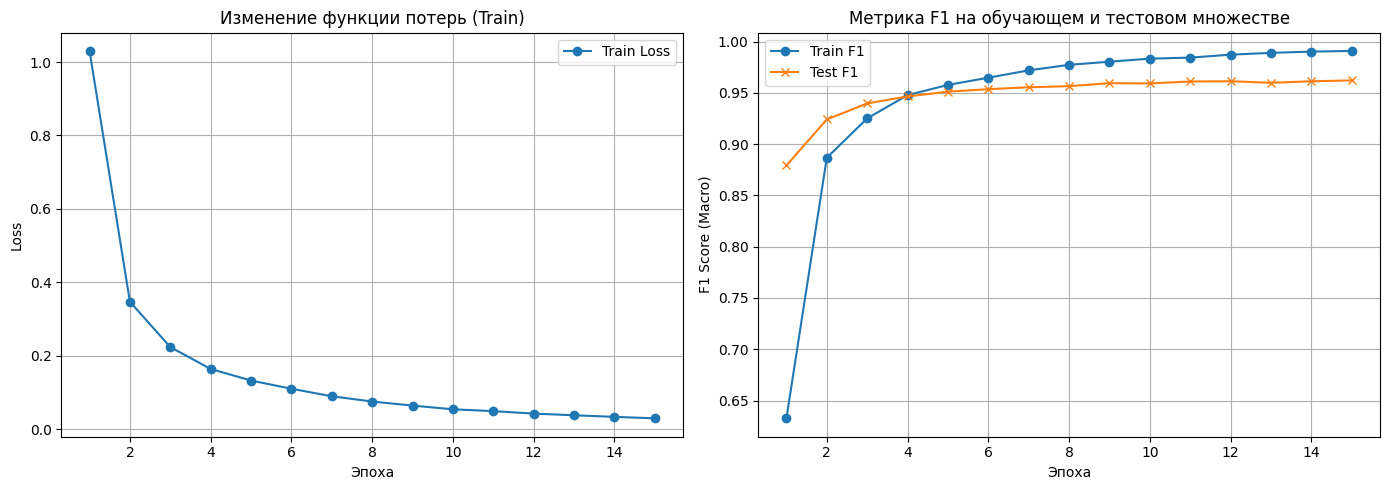

In [24]:
epochs = range(1, len(model.history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, model.history['train_loss'], marker='o', label='Train Loss')
plt.title('Изменение функции потерь (Train)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, model.history['train_f1'], marker='o', label='Train F1')
plt.plot(epochs, model.history['test_f1'][1:], marker='x', label='Test F1')
plt.title('Метрика F1 на обучающем и тестовом множестве')
plt.xlabel('Эпоха')
plt.ylabel('F1 Score (Macro)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
def get_all_preds(model, dataloader):
    model.eval()
    all_preds =[]
    all_targets =[]
    
    with torch.no_grad():
        for x, y in tqdm(dataloader):
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    return all_targets, all_preds

target_names = list(train_dataset.label2id.keys())

y_train_true, y_train_pred = get_all_preds(model, train_loader)
print(classification_report(y_train_true, y_train_pred, target_names=target_names))
print("\n")

y_test_true, y_test_pred = get_all_preds(model, test_loader)
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

  0%|          | 0/149 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.99      1.00      1.00      4742
      Культура       1.00      1.00      1.00      4771
         Спорт       1.00      1.00      1.00      4778
     Экономика       1.00      0.99      1.00      4781

      accuracy                           1.00     19072
     macro avg       1.00      1.00      1.00     19072
  weighted avg       1.00      1.00      1.00     19072





  0%|          | 0/38 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.94      0.94      0.94      1190
      Культура       0.96      0.96      0.96      1200
         Спорт       0.99      0.98      0.99      1200
     Экономика       0.96      0.96      0.96      1200

      accuracy                           0.96      4790
     macro avg       0.96      0.96      0.96      4790
  weighted avg       0.96      0.96      0.96      4790



<p class="task" id="4"></p>

4\. Повторите решение задачи 3, создав слой `nn.Embedding` на основе предобученных векторов для слов русского языка и заморозив веса данного слоя. Для поиска векторов можете воспользоваться любым известным вам ресурсом. Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей.  

- [ ] Проверено на семинаре

In [26]:
path = r'data\navec_news_v1_1B_250K_300d_100q.tar' 
navec = Navec.load(path)

embedding_dim = 300 
vocab = tokenizer_ws.get_vocab()
vocab_size = len(vocab)

weights_matrix = np.zeros((vocab_size, embedding_dim))

words_found = 0
for word, idx in vocab.items():
    if word in navec:
        weights_matrix[idx] = navec[word]
        words_found += 1
    else:
        weights_matrix[idx] = navec.get('<unk>', np.random.normal(scale=0.6, size=(embedding_dim,)))

print(f"Найдено слов из словаря в Navec: {words_found} из {vocab_size}")

weights_tensor = torch.FloatTensor(weights_matrix)

Найдено слов из словаря в Navec: 39077 из 84613


In [27]:
path = r'data\navec_hudlit_v1_12B_500K_300d_100q.tar' 
navec = Navec.load(path)

embedding_dim = 300 
vocab = tokenizer_ws.get_vocab()
vocab_size = len(vocab)

weights_matrix = np.zeros((vocab_size, embedding_dim))

words_found = 0
for word, idx in vocab.items():
    if word in navec:
        weights_matrix[idx] = navec[word]
        words_found += 1
    else:
        weights_matrix[idx] = navec.get('<unk>', np.random.normal(scale=0.6, size=(embedding_dim,)))

print(f"Найдено слов из словаря в Navec: {words_found} из {vocab_size}")

weights_tensor = torch.FloatTensor(weights_matrix)

Найдено слов из словаря в Navec: 44166 из 84613


так уж и быть. Возьмем бОльший файл navec

In [ ]:
class NavecFreezeIvanTishchenkoPL(IvanTishchenkoPL):
    def __init__(self, weights, num_classes=4, padding_idx=0):
        super().__init__(
            vocab_size=weights.shape[0], 
            embed_dim=weights.shape[1], 
            num_classes=num_classes, 
            padding_idx=padding_idx
        )
        
        self.embedding = nn.Embedding.from_pretrained(
            weights, 
            freeze=True,
            padding_idx=padding_idx
        )

pretrained_model = NavecFreezeIvanTishchenkoPL(
    weights=weights_tensor,
    num_classes=4,
    padding_idx=0
)

In [ ]:
trainer_pretrained = pl.Trainer(
    max_epochs=15,
    log_every_n_steps=10,
    accelerator='auto'
)

start_time = time.time()
trainer_pretrained.fit(pretrained_model, train_loader, test_loader)
end_time = time.time()

print(f"Время обучения с замороженными эмбеддингами: {end_time - start_time:.2f} секунд")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | embedding  | Embedding         | 25.4 M | train
1 | classifier | Sequential        | 19.5 K | train
2 | train_f1   | MulticlassF1Score | 0      | train
3 | test_f1    | MulticlassF1Score | 0      | train
---------------------------------------------------------
19.5 K    Trainable params
25.4 M    Non-trainable params
25.4 M    Total params
101.614   Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


Время обучения с замороженными эмбеддингами: 95.71 секунд


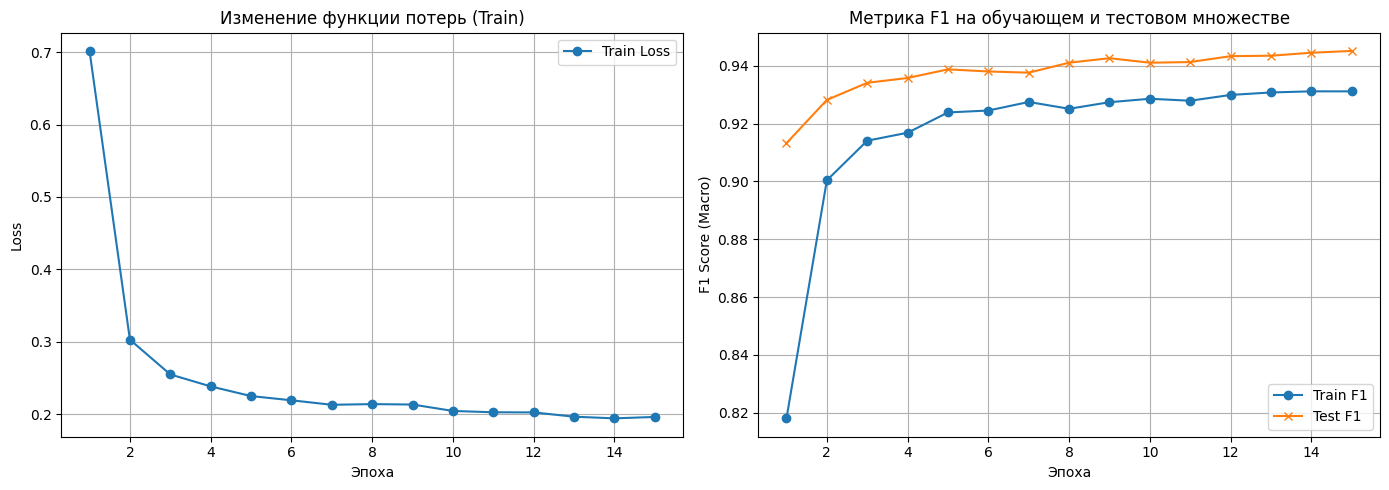

In [ ]:
epochs = range(1, len(pretrained_model.history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, pretrained_model.history['train_loss'], marker='o', label='Train Loss')
plt.title('Изменение функции потерь (Train)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, pretrained_model.history['train_f1'], marker='o', label='Train F1')
plt.plot(epochs, pretrained_model.history['test_f1'][1:], marker='x', label='Test F1')
plt.title('Метрика F1 на обучающем и тестовом множестве')
plt.xlabel('Эпоха')
plt.ylabel('F1 Score (Macro)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_train_true, y_train_pred = get_all_preds(pretrained_model, train_loader)
print(classification_report(y_train_true, y_train_pred, target_names=target_names))
print("\n")

y_test_true, y_test_pred = get_all_preds(pretrained_model, test_loader)
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

  0%|          | 0/149 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.92      0.91      0.92      4742
      Культура       0.96      0.96      0.96      4777
         Спорт       0.98      0.98      0.98      4775
     Экономика       0.94      0.94      0.94      4778

      accuracy                           0.95     19072
     macro avg       0.95      0.95      0.95     19072
  weighted avg       0.95      0.95      0.95     19072





  0%|          | 0/38 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.90      0.91      0.91      1190
      Культура       0.95      0.96      0.96      1200
         Спорт       0.99      0.98      0.99      1200
     Экономика       0.93      0.93      0.93      1200

      accuracy                           0.95      4790
     macro avg       0.95      0.95      0.95      4790
  weighted avg       0.95      0.95      0.95      4790



При идентичных прочих гиперпараметрах, мождель на предобученных замороженных эмбеддингах показала себя хуже, чем на необученных незамороженных. И по врменени  тоже дольше в 4 раза

<p class="task" id="5"></p>

5\. Повторите решение задачи 3, не замораживая веса слоя эмбеддингов. Сравните качество полученного решения и решений из предыдущих задач, а также время, затраченное на обучения моделей.  

- [ ] Проверено на семинаре

In [32]:
class NavecIvanTishchenkoPL(IvanTishchenkoPL):
    def __init__(self, weights, num_classes=4, padding_idx=0):
        super().__init__(
            vocab_size=weights.shape[0], 
            embed_dim=weights.shape[1], 
            num_classes=num_classes, 
            padding_idx=padding_idx
        )
        
        self.embedding = nn.Embedding.from_pretrained(
            weights, 
            freeze=False,
            padding_idx=padding_idx
        )

pretrained_model_unf = NavecIvanTishchenkoPL(
    weights=weights_tensor,
    num_classes=4,
    padding_idx=0
)

In [33]:
trainer_pretrained_unf= pl.Trainer(
    max_epochs=15,
    log_every_n_steps=10,
    accelerator='auto'
)

start_time = time.time()
trainer_pretrained_unf.fit(pretrained_model_unf, train_loader, test_loader)
end_time = time.time()

print(f"Время обучения с размороженными эмбеддингами: {end_time - start_time:.2f} секунд")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | embedding  | Embedding         | 25.4 M | train
1 | classifier | Sequential        | 19.5 K | train
2 | train_f1   | MulticlassF1Score | 0      | train
3 | test_f1    | MulticlassF1Score | 0      | train
---------------------------------------------------------
25.4 M    Trainable params
0         Non-trainable params
25.4 M    Total params
101.614   Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Projects\FU\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


Время обучения с размороженными эмбеддингами: 115.77 секунд


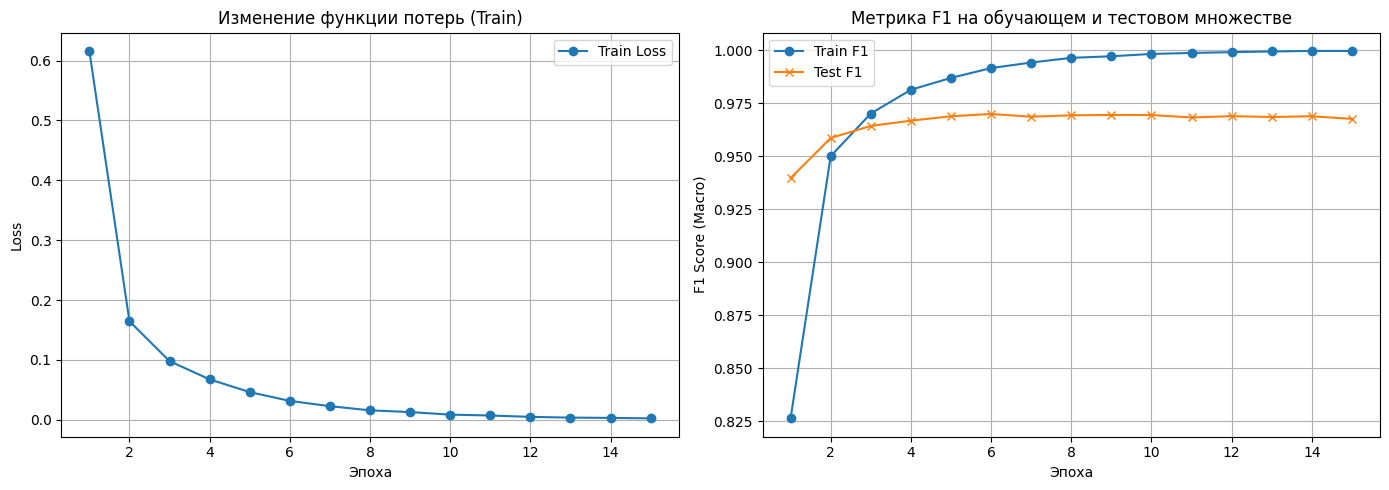

In [34]:
epochs = range(1, len(pretrained_model_unf.history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, pretrained_model_unf.history['train_loss'], marker='o', label='Train Loss')
plt.title('Изменение функции потерь (Train)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, pretrained_model_unf.history['train_f1'], marker='o', label='Train F1')
plt.plot(epochs, pretrained_model_unf.history['test_f1'][1:], marker='x', label='Test F1')
plt.title('Метрика F1 на обучающем и тестовом множестве')
plt.xlabel('Эпоха')
plt.ylabel('F1 Score (Macro)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
y_train_true, y_train_pred = get_all_preds(pretrained_model_unf, train_loader)
print(classification_report(y_train_true, y_train_pred, target_names=target_names))
print("\n")

y_test_true, y_test_pred = get_all_preds(pretrained_model_unf, test_loader)
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

  0%|          | 0/149 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       1.00      1.00      1.00      4737
      Культура       1.00      1.00      1.00      4774
         Спорт       1.00      1.00      1.00      4778
     Экономика       1.00      1.00      1.00      4783

      accuracy                           1.00     19072
     macro avg       1.00      1.00      1.00     19072
  weighted avg       1.00      1.00      1.00     19072





  0%|          | 0/38 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.94      0.94      0.94      1190
      Культура       0.97      0.97      0.97      1200
         Спорт       1.00      0.99      1.00      1200
     Экономика       0.96      0.96      0.96      1200

      accuracy                           0.97      4790
     macro avg       0.97      0.97      0.97      4790
  weighted avg       0.97      0.97      0.97      4790



<p class="task" id="6"></p>

6\. Постройте матрицу ошибок для лучшей модели на тестовой выборке. Прокомментируйте, какие классы модель путает чаще всего.

Визуализируйте эмбеддинги новостей из тестовой выборки в двумерном пространстве. Для проекции точек в двумерное пространство воспользуйтесь алгоритмом t-SNE. Раскрасьте точки в цвет, соответствующий классу новости. Прокомментируйте, видно ли разделение на кластеры по классу новостей.

- [ ] Проверено на семинаре

In [37]:
print("Без предобученных эмбеддингов:")
y_test_true, y_test_pred = get_all_preds(model, test_loader)
print(classification_report(y_test_true, y_test_pred, target_names=target_names))


print("Предобученные замороженные эмбеддинги:")
y_test_true, y_test_pred = get_all_preds(pretrained_model, test_loader)
print(classification_report(y_test_true, y_test_pred, target_names=target_names))


print("Предобученные размороженные эмбеддинги:")
y_test_true, y_test_pred = get_all_preds(pretrained_model_unf, test_loader)
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

Без предобученных эмбеддингов:


  0%|          | 0/38 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.94      0.94      0.94      1190
      Культура       0.96      0.96      0.96      1200
         Спорт       0.99      0.98      0.99      1200
     Экономика       0.96      0.96      0.96      1200

      accuracy                           0.96      4790
     macro avg       0.96      0.96      0.96      4790
  weighted avg       0.96      0.96      0.96      4790

Предобученные замороженные эмбеддинги:


  0%|          | 0/38 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.90      0.91      0.91      1190
      Культура       0.95      0.96      0.96      1200
         Спорт       0.99      0.98      0.99      1200
     Экономика       0.93      0.93      0.93      1200

      accuracy                           0.95      4790
     macro avg       0.95      0.95      0.95      4790
  weighted avg       0.95      0.95      0.95      4790

Предобученные размороженные эмбеддинги:


  0%|          | 0/38 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Интернет и СМИ       0.94      0.94      0.94      1190
      Культура       0.97      0.97      0.97      1200
         Спорт       1.00      0.99      1.00      1200
     Экономика       0.96      0.96      0.96      1200

      accuracy                           0.97      4790
     macro avg       0.97      0.97      0.97      4790
  weighted avg       0.97      0.97      0.97      4790



Лучше всех себя показала модель с размороженными предобученными эмбеддингами. А самым "сомнительным" классом стал "Интернет и СМИ"

  0%|          | 0/38 [00:00<?, ?it/s]

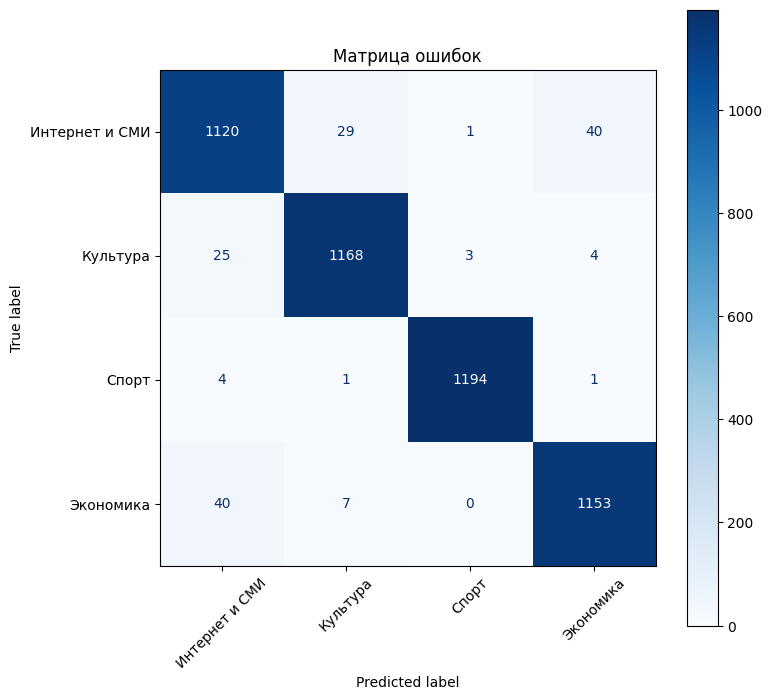

In [40]:
y_true, y_pred = get_all_preds(pretrained_model_unf, test_loader)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Матрица ошибок")
plt.show()

Это подтверждается матрицей ошибок $\Uparrow$

  0%|          | 0/38 [00:00<?, ?it/s]

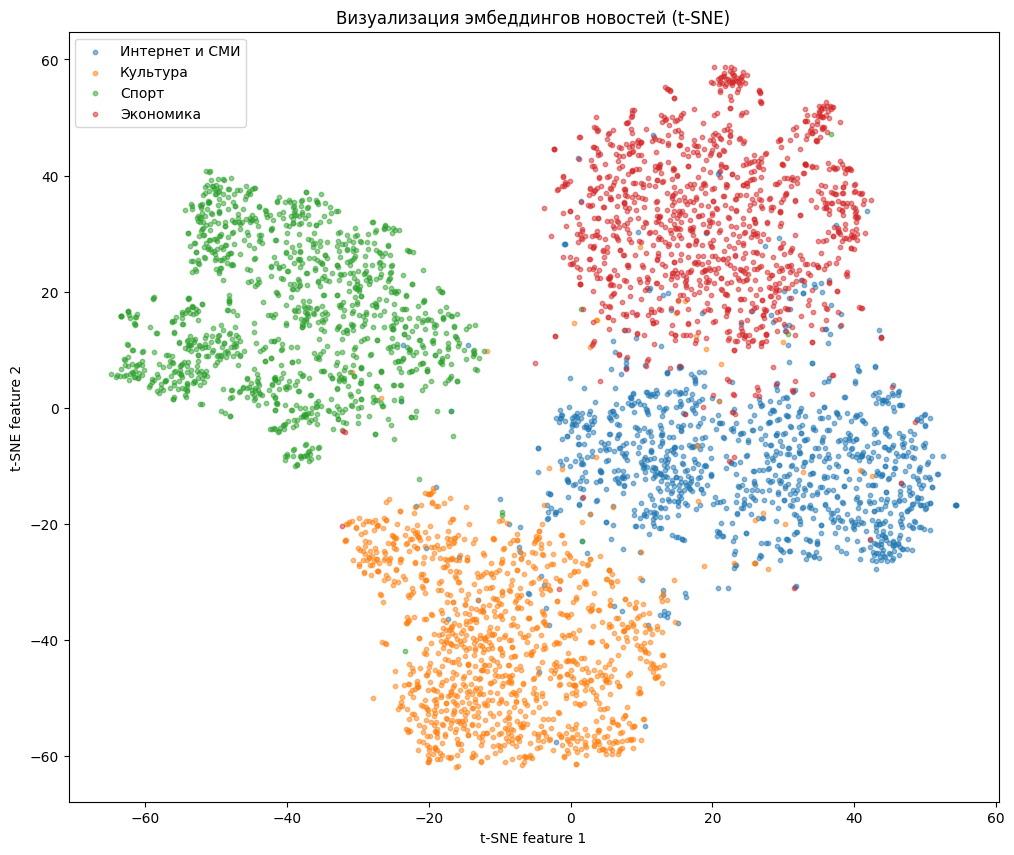

In [41]:
def get_embeddings_only(model, dataloader):
    model.eval()
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in tqdm(dataloader):
            embeds = model.embedding(x)
            mask = (x != model.hparams.padding_idx).float().unsqueeze(-1)
            sum_embeds = (embeds * mask).sum(dim=1)
            lengths = mask.sum(dim=1).clamp(min=1.0)
            avg_embeds = sum_embeds / lengths
            if avg_embeds.ndim == 3: 
                avg_embeds = avg_embeds.mean(dim=1)
            
            all_embeddings.append(avg_embeds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
            
    return np.vstack(all_embeddings), np.concatenate(all_labels)

X_emb, y_labels = get_embeddings_only(pretrained_model_unf, test_loader)

tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_emb)

plt.figure(figsize=(12, 10))
for i, label_name in enumerate(target_names):
    idx = (y_labels == i)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label_name, alpha=0.5, s=10)

plt.legend()
plt.title("Визуализация эмбеддингов новостей (t-SNE)")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.show()

Эмбеддинги построены успешно. Почти идеально разделяют кластеры новостей. Основная путаница возникает в классе "Интернет и СМИ". Это происходит потому, что лексика новостей о медиа часто пересекается с лексикой культуры и экономики.